In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

DB_PATH = Path("..") / "data" / "olist.db"
conn = sqlite3.connect(DB_PATH)

In [2]:
# Count orders
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""

pd.read_sql(query, conn)

,total_orders
0,99441


In [3]:
#Count customers
query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

pd.read_sql(query, conn)

,total_customers
0,99441


In [4]:
# Order Status Breakdown 
query = """
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""

pd.read_sql(query, conn)

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [5]:
#JOIN query
query = """
SELECT
    o.order_id,
    o.order_status,
    c.customer_city,
    c.customer_state
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
LIMIT 10;
"""

pd.read_sql(query, conn)

,order_id,order_status,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,santo andre,SP
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,congonhinhas,PR
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,santa rosa,RS
7,6514b8ad8028c9f2cc2374ded245783f,delivered,nilopolis,RJ
8,76c6e866289321a7c93b82b54852dc33,delivered,faxinalzinho,RS
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,sorocaba,SP


In [6]:
#  Monthly Orders
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS order_month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_month
ORDER BY order_month;
"""

monthly_orders = pd.read_sql(query, conn)
monthly_orders

,order_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


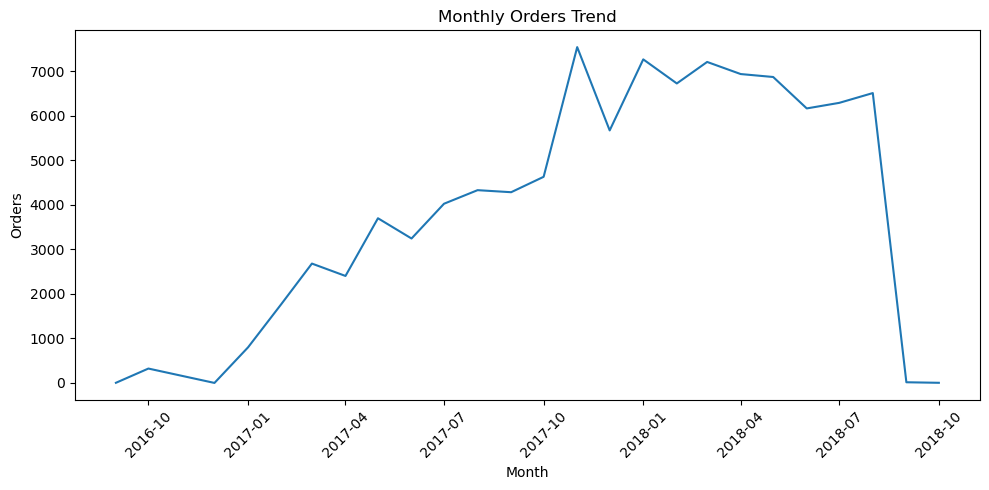

In [7]:
import matplotlib.pyplot as plt

monthly_orders["order_month"] = pd.to_datetime(monthly_orders["order_month"])

plt.figure(figsize=(10,5))
plt.plot(monthly_orders["order_month"], monthly_orders["total_orders"])
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Order volume grew significantly from 2016 to 2018, indicating rapid marketplace expansion. Peak demand appears in late 2017 and early 2018, suggesting seasonal or promotional effects.

In [8]:
# Monthly Revenue 
query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS order_month,
        SUM(oi.price + oi.freight_value) AS total_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY order_month
)

SELECT
    order_month,
    ROUND(total_revenue, 2) AS total_revenue,
    total_orders,
    ROUND(total_revenue / total_orders, 2) AS avg_order_value
FROM monthly_sales
ORDER BY order_month;
"""

monthly_sales = pd.read_sql(query, conn)
monthly_sales


,order_month,total_revenue,total_orders,avg_order_value
0,2016-09,143.46,1,143.46
1,2016-10,46490.66,265,175.44
2,2016-12,19.62,1,19.62
3,2017-01,127482.37,750,169.98
4,2017-02,271239.32,1653,164.09
5,2017-03,414330.95,2546,162.74
6,2017-04,390812.40,2303,169.70
7,2017-05,566851.40,3546,159.86
8,2017-06,490050.37,3135,156.32
9,2017-07,566299.08,3872,146.25


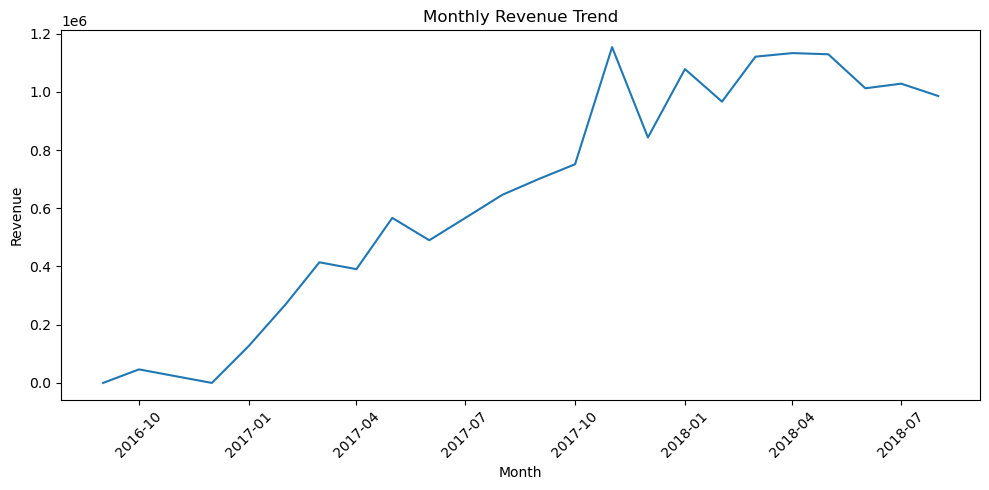

In [9]:
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["order_month"], monthly_sales["total_revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
#Top Product Categories
query = """
WITH category_sales AS (
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name) AS category,
        SUM(oi.price + oi.freight_value) AS total_revenue,
        COUNT(DISTINCT oi.order_id) AS total_orders
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
)

SELECT *
FROM category_sales
ORDER BY total_revenue DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query, conn)
top_categories

,category,total_revenue,total_orders
0,health_beauty,1412089.53,8647
1,watches_gifts,1264333.12,5495
2,bed_bath_table,1225209.26,9272
3,sports_leisure,1118256.91,7530
4,computers_accessories,1032723.77,6530
5,furniture_decor,880329.92,6307
6,housewares,758392.25,5743
7,cool_stuff,691680.89,3559
8,auto,669454.75,3810
9,garden_tools,567145.68,3448


Top Revenue Categories 
1. health_beauty
Revenue : 1.4 M
Orders : 8647

2. watches_gifts
Revenue: 1.2M
Orders : 5495 
More revenue than number of orders

3.bed_bath_table
Revenue: 1.23M
Orders: 9272 
Higher revenue with high number of orders.


In [11]:
#Rank Categories by Revenue
query = """
WITH category_sales AS (
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name) AS category,
        SUM(oi.price + oi.freight_value) AS total_revenue
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
)

SELECT
    category,
    ROUND(total_revenue,2) AS total_revenue,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM category_sales;
"""

ranked_categories = pd.read_sql(query, conn)
ranked_categories.head(10)

,category,total_revenue,revenue_rank
0,health_beauty,1412089.53,1
1,watches_gifts,1264333.12,2
2,bed_bath_table,1225209.26,3
3,sports_leisure,1118256.91,4
4,computers_accessories,1032723.77,5
5,furniture_decor,880329.92,6
6,housewares,758392.25,7
7,cool_stuff,691680.89,8
8,auto,669454.75,9
9,garden_tools,567145.68,10


In [12]:
# Repeat Customer Analysis 
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count,
        SUM(oi.price + oi.freight_value) AS total_spend
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time Customer'
        WHEN order_count BETWEEN 2 AND 3 THEN 'Repeat Customer'
        ELSE 'Loyal Customer'
    END AS customer_segment,
    COUNT(*) AS customers,
    ROUND(AVG(total_spend),2) AS avg_spend
FROM customer_orders
GROUP BY customer_segment
ORDER BY avg_spend DESC;
"""

customer_segments = pd.read_sql(query, conn)
customer_segments 

,customer_segment,customers,avg_spend
0,Loyal Customer,47,788.13
1,Repeat Customer,2754,300.34
2,One-time Customer,90557,160.73


In [13]:
# Delivery Delay vs Review Score 
query = """
WITH delivery_reviews AS (
    SELECT
        o.order_id,
        r.review_score,
        julianday(o.order_delivered_customer_date) -
        julianday(o.order_estimated_delivery_date) AS delay_days
    FROM orders o
    JOIN reviews r
        ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)

SELECT
    CASE
        WHEN delay_days <= 0 THEN 'On Time or Early'
        WHEN delay_days BETWEEN 1 AND 3 THEN '1-3 Days Late'
        WHEN delay_days BETWEEN 4 AND 7 THEN '4-7 Days Late'
        ELSE '8+ Days Late'
    END AS delivery_status,
    COUNT(*) AS total_orders,
    ROUND(AVG(review_score),2) AS avg_review_score
FROM delivery_reviews
GROUP BY delivery_status
ORDER BY avg_review_score DESC;
"""

delivery_reviews = pd.read_sql(query, conn)
delivery_reviews

,delivery_status,total_orders,avg_review_score
0,On Time or Early,88653,4.29
1,1-3 Days Late,1360,3.51
2,8+ Days Late,5059,2.41
3,4-7 Days Late,1281,2.17


As delivery delays increase, review scores drop.
Customers receiving orders on time rated their experience significantly higher than those receiving delayed deliveries. Orders delayed by more than 8 days had review scores nearly 2 points lower, suggesting logistics performance is a key driver of customer satisfaction